# CARBANAK tree coarsening experiment

I'm going to do some basic training on the pre-attack data, fitting on post-attack data.


## 0. Imports and local package path

This imports the source tree next to the notebook, even if another editable installation exists in the active kernel.


In [1]:
from pathlib import Path
import os
import sys
import math
from collections import Counter
import pickle

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from IPython.display import display
import re

from tree_coarsening import EdgeBPECoarsener, ParametricStarCoarsener
import tree_coarsening as tc
import glob

## 1. Data paths


In [2]:
DATA_DIR = Path("../../data/CARBANAK")
graph_files = list((DATA_DIR / "graphs").glob("*.pkl"))

In [3]:
# We're splitting test/train on date, so look at dates appearing in data.
np.unique([str(x).split("_d")[1].split(".")[0] for x in graph_files])

array(['01_05_2024', '01_05_2024_10', '01_05_2024_100', ...,
       '30_04_2024_97', '30_04_2024_98', '30_04_2024_99'],
      shape=(4317,), dtype='<U14')

## 2. Load trees


In [4]:
process_trees = []
bad_graph_files = []

for graph_path in graph_files:
    try:
        with graph_path.open("rb") as handle:
            process_tree = pickle.load(handle)
        process_trees.append([process_tree, graph_path])

    except Exception as e:
        print(f"FAILED: {graph_path}")
        print(f"  {type(e).__name__}: {e}")
        bad_graph_files.append((graph_path, e))

#print(process_tree.graph)
#first_node = next(iter(process_tree.nodes))
#print(first_node, process_tree.nodes[first_node])

bad_graph_files

[]

In [5]:
# What are vertex labels

G = process_trees[0][0]

node_attribute_names = sorted({
    attr_name
    for node, attrs in G.nodes(data=True)
    for attr_name in attrs.keys()
})

node_attribute_names[0:3]

['action', 'alert_id', 'alert_labels']

In [6]:
# do pre/post attack split

attacked_graphs = []
background_graphs = []

attr_name = "is_malicious"
for i in range(len(process_trees)):
    x = process_trees[i]
    G = x[0]
    values = [G.nodes[node].get(attr_name) for node in G.nodes()]
    if True in values:
        attacked_graphs.append(i)
    else:
        background_graphs.append(i)

print(len(attacked_graphs))
print(len(background_graphs))


35
4900


In [7]:
attr_name="first_seen"
[G.nodes[node].get(attr_name) for node in G.nodes()][0:10]

[datetime.datetime(2024, 4, 24, 18, 58, 57, 647365, tzinfo=datetime.timezone.utc)]

## 3. Fit and apply the coarsener

`d` is the witness threshold, `m` is the number of witnesses needed to learn a `(parent_label, child_label)` pair, and `contract_d` is the smaller transform-time threshold after the pair has been learned.


In [8]:
# Need to normalize the attribute names for the coarsener library.

def scalar_ok(value) -> bool:
    if value is None:
        return False
    try:
        if pd.isna(value):
            return False
    except Exception:
        pass
    if isinstance(value, (dict, list, tuple, set)):
        return False
    return str(value).strip() != ""

_PROCESS_BASENAME_RE = re.compile(
    r"(?i)([A-Za-z0-9_.~$@#%+=(){}\[\]-]+\.(?:exe|com|bat|cmd|ps1|vbs|js|jse|wsf|scr|msi|dll|sys|tmp|bin))"
)

def short_process_name(value):
    """Return a short process label such as 'cmd.exe' from a name/path/cmdline-like field."""
    if not scalar_ok(value):
        return ""
    s = str(value).strip().strip("'\"")
    if not s or s.lower() in {"none", "null", "nan", "<na>"}:
        return ""

    # If there is an executable-looking token anywhere in the path/cmdline, use its basename.
    normalized = s.replace("\\", "/")
    matches = _PROCESS_BASENAME_RE.findall(normalized)
    if matches:
        return matches[-1].lower()

    # Otherwise, if the field looks path-like, take the last path component.
    if "/" in normalized:
        tail = normalized.rsplit("/", 1)[-1].strip("'\" ")
        if tail:
            return tail.split()[0].lower()

    # Last resort: first whitespace-delimited token.
    return s.split()[0].lower()

from datetime import datetime, timezone
import math

def coarsening_time(value):
    """Convert a timestamp-like value to the finite float expected by tree_coarsening."""
    if isinstance(value, bool):
        raise TypeError("time must not be bool")

    if isinstance(value, datetime):
        if value.tzinfo is None:
            # Choose this policy only if your naive datetimes should mean UTC.
            value = value.replace(tzinfo=timezone.utc)
        out = value.timestamp()
    else:
        out = float(value)

    if not math.isfinite(out):
        raise ValueError(f"time must be finite; got {value!r}")

    return out

def simple_identity(value):
    return value

In [9]:
for i in range(len(process_trees)):
    G = process_trees[i][0]
    for node, attrs in G.nodes(data=True):
        attrs["label"] = short_process_name(attrs.get("process_path"))
    process_trees[i][0] = G

for i in range(len(process_trees)):
    G = process_trees[i][0]
    for node, attrs in G.nodes(data=True):
        attrs["time"] = coarsening_time(attrs.get("first_seen"))
    process_trees[i][0] = G

for i in range(len(process_trees)):
    G = process_trees[i][0]
    for node, attrs in G.nodes(data=True):
        attrs["uid"] = simple_identity(attrs.get("process_guid"))
    process_trees[i][0] = G

for i in range(len(process_trees)):
    G = process_trees[i][0]
    for node, attrs in G.nodes(data=True):
        attrs.pop("type", None)
    process_trees[i][0] = G


In [10]:
STAR_D = 4
STAR_M = 2
STAR_CONTRACT_D = 3

star = ParametricStarCoarsener(d=STAR_D, m=STAR_M, contract_d=STAR_CONTRACT_D)
star.fit([process_trees[x][0] for x in background_graphs])
train_stars = [star.transform(process_trees[x][0]) for x in background_graphs]


BPE_NUM_MERGES = 500
BPE_MIN_PAIR_COUNT = 2
BPE_BACKEND = "python"   # set to "numba" for warmed optimized BPE if numba is installed

bpe = EdgeBPECoarsener(
    num_merges=BPE_NUM_MERGES,
    min_pair_count=BPE_MIN_PAIR_COUNT,
    backend=BPE_BACKEND,
)
bpe.fit(train_stars)

result_trees = [bpe.transform(star.transform(process_trees[x][0])) for x in attacked_graphs]

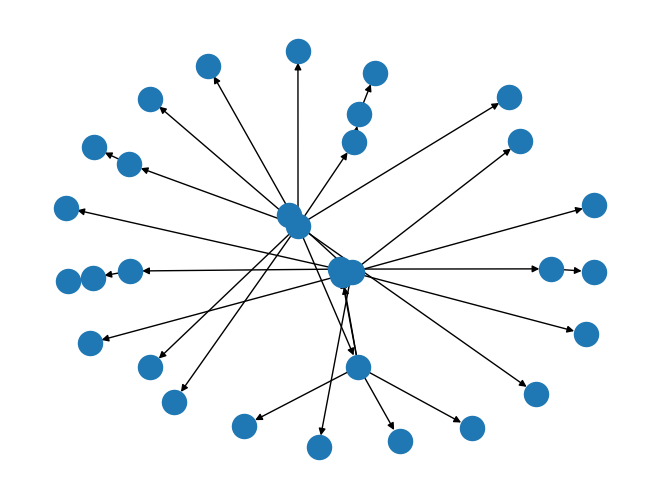

In [14]:
nx.draw(result_trees[0])

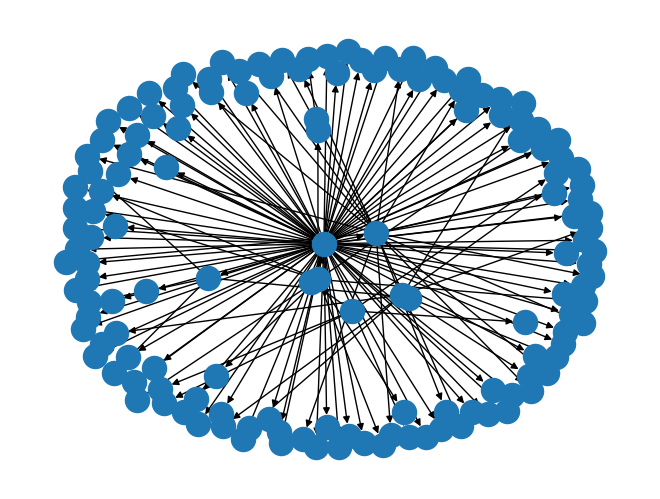

In [16]:
nx.draw(process_trees[attacked_graphs[0]][0])